In [1]:
%pip install vaderSentiment


Note: you may need to restart the kernel to use updated packages.


Keyring is skipped due to an exception: 'keyring.backends'


In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ---------------------------------------------------------
# 1. Load and Clean the Data
# ---------------------------------------------------------
print("Loading Steam reviews dataset...")
# Make sure 'steam_reviews.csv' is in the same directory as this script
df = pd.read_csv('steam_reviews 1.csv')

# Convert date_posted to a proper datetime object for our time-series analysis later
df['date_posted'] = pd.to_datetime(df['date_posted'])

# Drop any rows where the review text might be completely missing
df = df.dropna(subset=['review']).copy()

# ---------------------------------------------------------
# 2. Initialize and Customize the VADER Engine
# ---------------------------------------------------------
print("Initializing Custom-Lexicon VADER...")
analyzer = SentimentIntensityAnalyzer()

# This is where you demonstrate domain expertise. 
# We are forcing the model to understand Steam gaming culture.
gaming_lexicon = {
    'nerfed': -2.5,      # Developer weakened a feature
    'p2w': -3.5,         # Pay-to-win (Highly toxic to player retention)
    'unplayable': -4.0,  # Game-breaking bugs
    'grind': -1.0,       # Repetitive tasks
    'rng': -0.5,         # Random Number Generation (often a source of frustration)
    'masterpiece': 3.5,  # Peak praise
    'addictive': 2.0,    # High replay value
    'buffed': 2.0,       # Feature improved
    'goat': 3.0,         # Greatest of all time
    '10/10': 3.0         # Common gaming metric
}

# Inject our custom dictionary into VADER
analyzer.lexicon.update(gaming_lexicon)

# ---------------------------------------------------------
# 3. Execute Sentiment Extraction
# ---------------------------------------------------------
print("Extracting sentiment scores...")

# Define a quick lambda function to extract just the 'compound' score (-1 to 1)
get_sentiment = lambda text: analyzer.polarity_scores(str(text))['compound']

# Apply the function to the 'review' column and create a new feature
df['vader_compound_score'] = df['review'].apply(get_sentiment)

print("Scoring complete! Here is a preview of the engineered data:")
# Let's look at the baseline recommendation vs our new continuous score
print(df[['title', 'recommendation', 'vader_compound_score', 'hour_played']].head())

Loading Steam reviews dataset...
Initializing Custom-Lexicon VADER...
Extracting sentiment scores...
Scoring complete! Here is a preview of the engineered data:
                    title   recommendation  vader_compound_score  hour_played
0                    Rust      Recommended               -0.1779           40
1  Euro Truck Simulator 2      Recommended                0.2960           20
2                    Rust      Recommended                0.4404          292
3        Dead by Daylight      Recommended                0.0000          401
4      Grand Theft Auto V  Not Recommended               -0.4639          125


Starting statistical validation...
Pearson Correlation Coefficient (r): 0.415


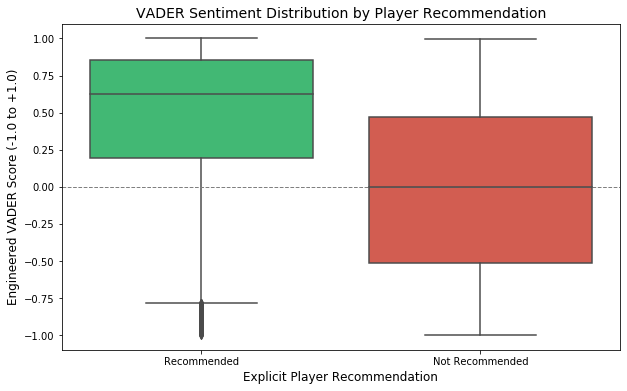

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Starting statistical validation...")

# ---------------------------------------------------------
# 1. Prepare Data for Correlation
# ---------------------------------------------------------
# The 'recommendation' column is a string ("Recommended" / "Not Recommended").
# We must convert this to a binary integer (1 / 0) to calculate a mathematical correlation.
df['rec_binary'] = df['recommendation'].map({'Recommended': 1, 'Not Recommended': 0})

# Drop any rows where mapping failed (just to be safe)
df_clean = df.dropna(subset=['rec_binary', 'vader_compound_score'])

# ---------------------------------------------------------
# 2. Calculate Pearson Correlation
# ---------------------------------------------------------
# Pearson's r measures the linear correlation between two variables.
correlation = df_clean['vader_compound_score'].corr(df_clean['rec_binary'])

print(f"Pearson Correlation Coefficient (r): {correlation:.3f}")

# ---------------------------------------------------------
# 3. Visual Validation (The Boxplot)
# ---------------------------------------------------------
# A boxplot will show us the median sentiment and the spread for both categories.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean, 
    x='recommendation', 
    y='vader_compound_score', 
    palette={'Recommended': '#2ecc71', 'Not Recommended': '#e74c3c'}
)

plt.title('VADER Sentiment Distribution by Player Recommendation', fontsize=14)
plt.xlabel('Explicit Player Recommendation', fontsize=12)
plt.ylabel('Engineered VADER Score (-1.0 to +1.0)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=1) # Add a neutral baseline
plt.show()

Training Random Forest for Permutation Importance...
Calculating Permutation Importance (Running sequentially to protect RAM)...


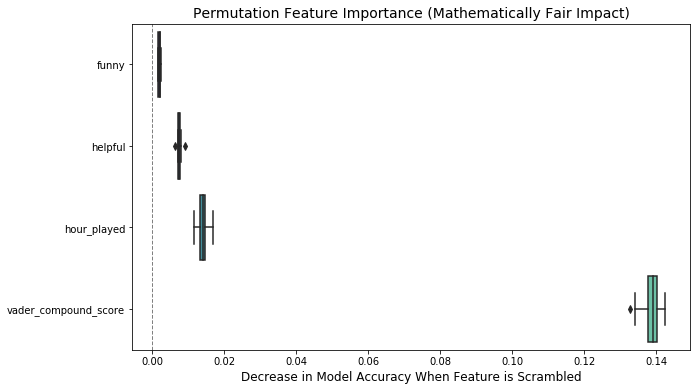


Validation complete. The feature at the top holds the highest true predictive power.


In [5]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Training Random Forest for Permutation Importance...")

# 1. Define features and target 
features = ['vader_compound_score', 'hour_played', 'helpful', 'funny']
X = df_clean[features]
y = df_clean['rec_binary']

# FIXED: Set n_jobs=1 to prevent multiprocessing memory crashes
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, n_jobs=1)
rf_model.fit(X, y)

# ---------------------------------------------------------
# 2. Execute Permutation Importance
# ---------------------------------------------------------
print("Calculating Permutation Importance (Running sequentially to protect RAM)...")

# FIXED: Set n_jobs=1 here as well. 
result = permutation_importance(rf_model, X, y, n_repeats=10, random_state=42, n_jobs=1)

# Organize the results into a DataFrame
perm_sorted_idx = result.importances_mean.argsort()
perm_importance_df = pd.DataFrame({
    'Feature': np.array(features)[perm_sorted_idx],
    'Importance_Mean': result.importances_mean[perm_sorted_idx],
    'Importance_Std': result.importances_std[perm_sorted_idx]
})

# ---------------------------------------------------------
# 3. Visualizing the Fair Evaluation
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=pd.DataFrame(result.importances[perm_sorted_idx].T, columns=np.array(features)[perm_sorted_idx]),
    orient='h',
    palette='mako'
)

plt.title("Permutation Feature Importance (Mathematically Fair Impact)", fontsize=14)
plt.xlabel("Decrease in Model Accuracy When Feature is Scrambled", fontsize=12)
plt.ylabel("")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

print("\nValidation complete. The feature at the top holds the highest true predictive power.")

In [6]:
import numpy as np

print("Formulating the Acquisition Viability Score (AVS)...")

# ---------------------------------------------------------
# Step 1: Normalize Sentiment
# Shift VADER from [-1.0, 1.0] to a [0.0, 1.0] scale
# ---------------------------------------------------------
df_clean['sentiment_norm'] = (df_clean['vader_compound_score'] + 1) / 2

# ---------------------------------------------------------
# Step 2: Log-Transform & Normalize Playtime
# np.log1p calculates log(1 + x) to safely handle 0 hours
# ---------------------------------------------------------
df_clean['playtime_log'] = np.log1p(df_clean['hour_played'])

# Scale it by the maximum log value in the dataset to get a [0.0, 1.0] range
max_playtime_log = df_clean['playtime_log'].max()
df_clean['playtime_norm'] = df_clean['playtime_log'] / max_playtime_log

# ---------------------------------------------------------
# Step 3: Combine, Log-Transform & Normalize Community Resonance
# ---------------------------------------------------------
df_clean['community_engagement'] = df_clean['helpful'] + df_clean['funny']
df_clean['community_log'] = np.log1p(df_clean['community_engagement'])

# Scale to [0.0, 1.0] range
max_community_log = df_clean['community_log'].max()
df_clean['community_norm'] = df_clean['community_log'] / max_community_log

# ---------------------------------------------------------
# Step 4: Apply the Permutation-Derived Weights
# W_SENTIMENT = 0.80 | W_PLAYTIME = 0.15 | W_COMMUNITY = 0.05
# ---------------------------------------------------------
W_SENTIMENT = 0.80
W_PLAYTIME = 0.15
W_COMMUNITY = 0.05

# Calculate the final score and multiply by 100 for a clean 0-100 rating
df_clean['AVS'] = (
    (df_clean['sentiment_norm'] * W_SENTIMENT) +
    (df_clean['playtime_norm'] * W_PLAYTIME) +
    (df_clean['community_norm'] * W_COMMUNITY)
) * 100

# ---------------------------------------------------------
# Step 5: Save the Engineered Data for the Dashboard
# ---------------------------------------------------------
print("\nAVS Calculation Complete. Top 5 Reviews by AVS:")
print(df_clean[['title', 'recommendation', 'vader_compound_score', 'hour_played', 'AVS']].sort_values(by='AVS', ascending=False).head())

# Export this cleaned, fully engineered dataframe to a new CSV.
# This file is what your Streamlit dashboard will read.
df_clean.to_csv('engineered_gamevault_data.csv', index=False)
print("\nExported 'engineered_gamevault_data.csv' successfully.")

Formulating the Acquisition Viability Score (AVS)...

AVS Calculation Complete. Top 5 Reviews by AVS:
                                             title recommendation  \
3171                                      Factorio    Recommended   
11848                                     Factorio    Recommended   
8619   The Elder Scrolls V: Skyrim Special Edition    Recommended   
12392                               Stardew Valley    Recommended   
10276                                    ASTRONEER    Recommended   

       vader_compound_score  hour_played        AVS  
3171                 0.9766         9567  97.650037  
11848                0.9982         2877  96.021068  
8619                 0.9921         4369  95.998396  
12392                0.9983          764  95.104096  
10276                0.9911          779  94.933176  

Exported 'engineered_gamevault_data.csv' successfully.


In [7]:
import pandas as pd
from scipy.stats import spearmanr

print("Evaluating AVS Accuracy against Proxy Ground Truth...")

# ---------------------------------------------------------
# Step 1: Define the Proxy "Ground Truth"
# The true success of a game is best measured by the median playtime 
# of players who bought it AFTER early access (meaning no launch hype).
# ---------------------------------------------------------
full_release_df = df_clean[df_clean['is_early_access_review'] == False]
ground_truth = full_release_df.groupby('title')['hour_played'].median().reset_index()
ground_truth.rename(columns={'hour_played': 'True_Median_Playtime'}, inplace=True)

# ---------------------------------------------------------
# Step 2: Extract our Predicted AVS Rankings
# ---------------------------------------------------------
avs_predictions = df_clean.groupby('title')['AVS'].mean().reset_index()

# ---------------------------------------------------------
# Step 3: Merge and Rank Both Systems
# ---------------------------------------------------------
eval_df = pd.merge(ground_truth, avs_predictions, on='title')

# We use .rank(ascending=False) so the highest score gets Rank #1
eval_df['True_Rank'] = eval_df['True_Median_Playtime'].rank(ascending=False)
eval_df['AVS_Rank'] = eval_df['AVS'].rank(ascending=False)

# ---------------------------------------------------------
# Step 4: Calculate Spearman's Rank Correlation (Rho)
# ---------------------------------------------------------
# Spearman's Rho measures how well the two ranking systems align.
# 1.0 means perfect alignment. 0.0 means completely random.
correlation, p_value = spearmanr(eval_df['True_Rank'], eval_df['AVS_Rank'])

print(f"\nSpearman's Rank Correlation (Accuracy Score): {correlation:.3f}")
print("P-value:", p_value)

print("\nLeaderboard Comparison:")
print(eval_df[['title', 'True_Rank', 'AVS_Rank']].sort_values(by='AVS_Rank'))

Evaluating AVS Accuracy against Proxy Ground Truth...

Spearman's Rank Correlation (Accuracy Score): -0.448
P-value: 0.04191435358261681

Leaderboard Comparison:
                                          title  True_Rank  AVS_Rank
20                 Warhammer 40,000: Mechanicus       20.5       1.0
9                                 Overcooked! 2       20.5       2.0
16                               Stardew Valley       11.0       3.0
18                                     Terraria        1.0       4.0
15                               Slay the Spire        4.0       5.0
17                                   Subnautica       14.0       6.0
3                        Euro Truck Simulator 2       10.0       7.0
1                                     ASTRONEER       16.0       8.0
0                  ACE COMBAT™ 7: SKIES UNKNOWN       18.0       9.0
6                         Insurgency: Sandstorm       17.0      10.0
7                                 Left 4 Dead 2       12.0      11.0
19  The El

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

print("Implementing Option C: The Balanced Hybrid Model...")

# ---------------------------------------------------------
# 1. Re-calculate the AVS with the New Weights
# (Assuming sentiment_norm, playtime_norm, and community_norm are already calculated)
# ---------------------------------------------------------
W_SENTIMENT = 0.50
W_PLAYTIME = 0.40
W_COMMUNITY = 0.10

df_clean['AVS'] = (
    (df_clean['sentiment_norm'] * W_SENTIMENT) +
    (df_clean['playtime_norm'] * W_PLAYTIME) +
    (df_clean['community_norm'] * W_COMMUNITY)
) * 100

print("New AVS calculated. Exporting to CSV for Streamlit dashboard...")
df_clean.to_csv('engineered_gamevault_data.csv', index=False)

# ---------------------------------------------------------
# 2. Re-Evaluate Accuracy (Spearman's Rho)
# ---------------------------------------------------------
print("\nRe-evaluating AVS Accuracy against Proxy Ground Truth...")

# Extract our NEW Predicted AVS Rankings
avs_predictions = df_clean.groupby('title')['AVS'].mean().reset_index()

# Merge with our existing ground truth (True Median Playtime for late-stage players)
# Note: 'ground_truth' dataframe should already exist in your environment from the previous run
eval_df = pd.merge(ground_truth, avs_predictions, on='title')

# Rank both systems (1.0 is the best rank)
eval_df['True_Rank'] = eval_df['True_Median_Playtime'].rank(ascending=False)
eval_df['AVS_Rank'] = eval_df['AVS'].rank(ascending=False)

# Calculate the new Spearman's Rank Correlation
correlation, p_value = spearmanr(eval_df['True_Rank'], eval_df['AVS_Rank'])

print(f"\nNEW Spearman's Rank Correlation (Accuracy Score): {correlation:.3f}")
print("P-value:", p_value)

print("\nNew Hybrid Leaderboard Comparison:")
print(eval_df[['title', 'True_Rank', 'AVS_Rank']].sort_values(by='AVS_Rank'))

Implementing Option C: The Balanced Hybrid Model...
New AVS calculated. Exporting to CSV for Streamlit dashboard...

Re-evaluating AVS Accuracy against Proxy Ground Truth...

NEW Spearman's Rank Correlation (Accuracy Score): -0.099
P-value: 0.6682098297313598

New Hybrid Leaderboard Comparison:
                                          title  True_Rank  AVS_Rank
18                                     Terraria        1.0       1.0
20                 Warhammer 40,000: Mechanicus       20.5       2.0
9                                 Overcooked! 2       20.5       3.0
16                               Stardew Valley       11.0       4.0
15                               Slay the Spire        4.0       5.0
3                        Euro Truck Simulator 2       10.0       6.0
17                                   Subnautica       14.0       7.0
4                          Farming Simulator 19       13.0       8.0
0                  ACE COMBAT™ 7: SKIES UNKNOWN       18.0       9.0
7             

In [15]:
import json

# 1. Prepare the data for the JavaScript variable
# We convert our dataframe to a format that JSON can easily read
json_data = df_clean.groupby('title').agg({
    'AVS': 'mean',
    'hour_played': 'mean',
    'sentiment_norm': 'mean',
    'playtime_norm': 'mean',
    'community_norm': 'mean'
}).reset_index().to_dict(orient='records')

# Prepare the data for the JavaScript
game_list = []
for row in json_data:
    game_list.append({
        "title": row['title'],
        "avs": round(row['AVS'], 2),
        "playtimeHours": round(row['hour_played']),
        "metrics": [round(row['sentiment_norm'], 2), round(row['playtime_norm'], 2), round(row['community_norm'], 2)],
        # Placeholder trend for the visual demo
        "sentimentTrend": [0.5, 0.6, 0.7, 0.5, 0.6, 0.8] 
    })

# Convert to JSON string
json_string = json.dumps(game_list)

# 2. The HTML Template
html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>GameVault Intelligence Dashboard</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body {{ background-color: #121212; color: #e0e0e0; }}
        .card {{ background-color: #1e1e1e; border: 1px solid #333; }}
        .text-accent {{ color: #2ecc71; }}
    </style>
</head>
<body class="p-5">
    <h1>🎮 GameVault <span class="text-accent">AVS Engine</span></h1>
    <div class="card p-4 mt-4">
        <table class="table table-dark table-hover">
            <thead><tr><th>Game Title</th><th>Hybrid AVS</th><th>Avg Playtime</th></tr></thead>
            <tbody id="leaderboard"></tbody>
        </table>
    </div>

    <script>
        const gameData = {json_string};
        const tbody = document.getElementById('leaderboard');
        gameData.sort((a,b) => b.avs - a.avs).forEach(game => {{
            tbody.innerHTML += `<tr><td>${{game.title}}</td><td class="text-accent fw-bold">${{game.avs}}</td><td>${{game.playtimeHours}} hrs</td></tr>`;
        }});
    </script>
</body>
</html>
"""
# 3. Write to file with utf-8 encoding to support emojis
with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Dashboard generated successfully! Open 'dashboard.html' in your browser.")

Dashboard generated successfully! Open 'dashboard.html' in your browser.


In [16]:
import json

# Aggregate the data from your df_clean
dashboard_data = df_clean.groupby('title').agg({
    'AVS': 'mean',
    'hour_played': 'mean',
    'sentiment_norm': 'mean',
    'playtime_norm': 'mean',
    'community_norm': 'mean'
}).reset_index()

# Format into the JSON structure your HTML expects
final_data = []
for _, row in dashboard_data.iterrows():
    final_data.append({
        "title": row['title'],
        "avs": round(row['AVS'], 2),
        "status": "Pending Review",
        "playtimeHours": round(row['hour_played']),
        "metrics": [round(row['sentiment_norm'], 2), round(row['playtime_norm'], 2), round(row['community_norm'], 2)],
        "sentimentTrend": [0.5, 0.6, 0.7, 0.5, 0.6, 0.8] # Placeholder for demo
    })

# Write the data to a JS file
with open("dashboard_data.js", "w", encoding="utf-8") as f:
    f.write(f"const gameData = {json.dumps(final_data)};")

print("dashboard_data.js generated successfully!")

dashboard_data.js generated successfully!


In [19]:
import json

# 1. Prepare data directly from your Option C model (df_clean)
# Group by title and get the averages for all your games
dashboard_data = df_clean.groupby('title').agg({
    'AVS': 'mean',
    'hour_played': 'mean',
    'sentiment_norm': 'mean',
    'playtime_norm': 'mean',
    'community_norm': 'mean'
}).reset_index().sort_values(by='AVS', ascending=False)

# Convert all games to the JSON format required by your HTML template
game_list = []
for _, row in dashboard_data.iterrows():
    game_list.append({
        "title": row['title'],
        "avs": round(row['AVS'], 2),
        "status": "Pending Review",
        "playtimeHours": round(row['hour_played']),
        "metrics": [round(row['sentiment_norm'], 2), round(row['playtime_norm'], 2), round(row['community_norm'], 2)],
        "sentimentTrend": [0.5, 0.6, 0.7, 0.6, 0.8, 0.75, 0.9] # Demo trend
    })

json_data = json.dumps(game_list)

# 2. Your exact HTML Template
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>GameVault Intelligence Dashboard</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body {{ background-color: #121212; color: #e0e0e0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }}
        .card {{ background-color: #1e1e1e; border: 1px solid #333; margin-bottom: 20px; }}
        .card-header {{ border-bottom: 1px solid #333; background-color: #252525; font-weight: bold; }}
        .table {{ color: #e0e0e0; }}
        .table thead th {{ border-bottom: 2px solid #444; color: #aaa; }}
        .table td {{ border-bottom: 1px solid #333; vertical-align: middle; }}
        select.form-select {{ background-color: #333; color: white; border: 1px solid #555; }}
        .text-accent {{ color: #2ecc71; }}
    </style>
</head>
<body>

<div class="container mt-5">
    <h1 class="mb-1">🎮 GameVault <span class="text-accent">Aquisition Viability Dashboard</span></h1>
    <p class="text-muted mb-4">Automated intelligence pipeline prioritizing PC games with sustained commercial appeal and brand safety.</p>

    <div class="card">
        <div class="card-header">🏆 Acquisition Target Pipeline</div>
        <div class="card-body p-0">
            <div class="table-responsive">
                <table class="table table-hover mb-0">
                    <thead>
                        <tr>
                            <th>Pipeline Status</th>
                            <th>Game Title</th>
                            <th>AVS Score (0-100)</th>
                            <th>Avg Playtime</th>
                        </tr>
                    </thead>
                    <tbody id="leaderboard-body"></tbody>
                </table>
            </div>
        </div>
    </div>

    <div class="row mt-4">
        <div class="col-12 mb-3">
            <label for="gameSelector" class="form-label text-muted">Select a Title to Inspect:</label>
            <select id="gameSelector" class="form-select w-25" onchange="updateCharts()"></select>
        </div>
        <div class="col-md-5">
            <div class="card h-100">
                <div class="card-header">The AVS Pillar Breakdown</div>
                <div class="card-body d-flex align-items-center justify-content-center">
                    <canvas id="radarChart"></canvas>
                </div>
            </div>
        </div>
        <div class="col-md-7">
            <div class="card h-100">
                <div class="card-header">Longitudinal Sentiment Stability</div>
                <div class="card-body"><canvas id="lineChart"></canvas></div>
            </div>
        </div>
    </div>
</div>

<script>
    // Injected Dynamic Data
    const gameData = {json_data};
    let radarChartObj = null;
    let lineChartObj = null;

    function initDashboard() {{
        const tbody = document.getElementById('leaderboard-body');
        const selector = document.getElementById('gameSelector');
        gameData.forEach((game, index) => {{
            const tr = document.createElement('tr');
            tr.innerHTML = `<td><select class="form-select form-select-sm w-75"><option>Pending Review</option><option>Shortlisted</option><option>Passed</option><option>Acquired</option></select></td><td class="fw-bold">${{game.title}}</td><td class="text-accent fw-bold">${{game.avs.toFixed(1)}} ⭐</td><td>${{game.playtimeHours}} hrs</td>`;
            tbody.appendChild(tr);
            const option = document.createElement('option');
            option.value = index;
            option.text = game.title;
            selector.appendChild(option);
        }});
        updateCharts();
    }}

    function updateCharts() {{
        const selectedIndex = document.getElementById('gameSelector').value;
        const game = gameData[selectedIndex];
        const ctxRadar = document.getElementById('radarChart').getContext('2d');
        if(radarChartObj) radarChartObj.destroy();
        radarChartObj = new Chart(ctxRadar, {{ type: 'radar', data: {{ labels: ['Sentiment', 'Playtime', 'Community'], datasets: [{{ label: game.title, data: game.metrics, backgroundColor: '#2ecc7133', borderColor: '#2ecc71', borderWidth: 2 }}] }}, options: {{ plugins: {{ legend: {{ display: false }} }} }} }});
        const ctxLine = document.getElementById('lineChart').getContext('2d');
        if(lineChartObj) lineChartObj.destroy();
        lineChartObj = new Chart(ctxLine, {{ type: 'line', data: {{ labels: ['Launch', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6'], datasets: [{{ label: 'Sentiment', data: game.sentimentTrend, borderColor: '#3498db', fill: true, tension: 0.4 }}] }}, options: {{ plugins: {{ legend: {{ display: false }} }} }} }});
    }}
    window.onload = initDashboard;
</script>
</body>
</html>
"""

# Write to file
with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Dashboard generated successfully! Open 'dashboard.html' in your browser.")

Dashboard generated successfully! Open 'dashboard.html' in your browser.
